# Week 14 Lesson: GANs and Diffusion



#### Setup & Data

We'll use the Cartoon Faces dataset

In [ ]:
import torch
print(torch.__version__)
print("MPS available:", torch.backends.mps.is_available())


In [ ]:
# install once if needed:
#!pip -q install diffusers transformers accelerate safetensors

import torch
from diffusers import StableDiffusionPipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype  = torch.float16 if device == "mps" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    torch_dtype=dtype,
    use_safetensors=True,
).to(device)

img = pipe(
    "a watercolor of the Boston skyline at dusk, soft light, detailed",
    num_inference_steps=24, guidance_scale=7.0
).images[0]
img.save("sd_demo.png")
print("Saved sd_demo.png")


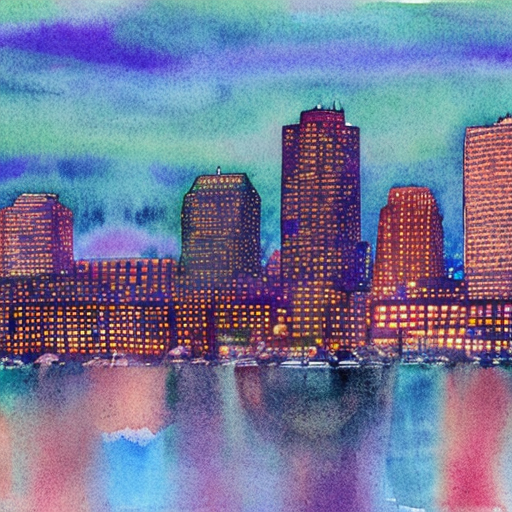

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype  = torch.float16 if device == "mps" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    torch_dtype=dtype,
    use_safetensors=True,
).to(device)

img = pipe("a watercolor of the Boston skyline at dusk, soft light, detailed",
           num_inference_steps=24, guidance_scale=7.0).images[0]
img.save("sd_demo.png")
print("Saved sd_demo.png")



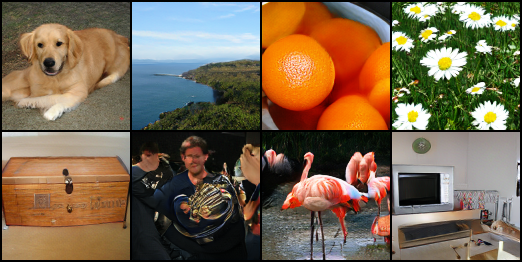

In [ ]:
import torch
import torch.nn.functional as F
from torchvision.utils import save_image, make_grid

c = 207  # single class to keep labels fixed
labels = torch.from_numpy(one_hot_from_int([c]*9, batch_size=9)).to(device)

z0 = torch.from_numpy(truncated_noise_sample(truncation=0.4, batch_size=1)).to(device)
z1 = torch.from_numpy(truncated_noise_sample(truncation=0.4, batch_size=1)).to(device)
alphas = torch.linspace(0,1,9, device=device).view(-1,1,1)
z = z0*(1-alphas) + z1*alphas

with torch.no_grad():
    imgs = (model(z, labels, 0.4).clamp(-1,1)+1)/2
grid = make_grid(imgs.to("cpu"), nrow=9)
save_image(grid, "biggan_interp.png")
print("Saved biggan_interp.png")


In [ ]:
# --- Install once (Colab) ---
!pip -q install diffusers transformers accelerate torch torchvision --upgrade

import torch
from diffusers import StableDiffusionPipeline

# Option 1: token inline (quick demo)
HF_TOKEN = "hf_..."   # paste your token string

# Load a recent SD model; 2.1-base is a solid default
pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    torch_dtype=torch.float16,
    use_safetensors=True,
    token=HF_TOKEN
).to("cuda")

# --- Text → Image ---
prompt = "a photorealistic portrait of a golden retriever astronaut, cinematic lighting, 35mm"
negative = "blurry, low quality, text, watermark, deformed"
image = pipe(prompt, negative_prompt=negative, num_inference_steps=30, guidance_scale=7.5).images[0]
image.save("sd_sample.png")
"Saved sd_sample.png"


In [ ]:
import random
g = torch.Generator(device="cuda").manual_seed(42)
img = pipe(prompt, negative_prompt=negative, generator=g,
           num_inference_steps=30, guidance_scale=7.5).images[0]
img.save("sd_seed42.png")


In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image

pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    torch_dtype=torch.float16,
    use_safetensors=True,
    token=HF_TOKEN
).to("cuda")

init_img = Image.open("sd_sample.png").convert("RGB").resize((512,512))
prompt2 = "convert this into a watercolor painting, high detail, soft edges"
result = pipe_i2i(prompt=prompt2, image=init_img, strength=0.6,
                  guidance_scale=8.0, num_inference_steps=30).images[0]
result.save("sd_i2i_watercolor.png")
"Saved sd_i2i_watercolor.png"
